<a href="https://colab.research.google.com/github/mmilyas245-dot/artificial_intelligence_coarse26/blob/main/civic1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the OpenAI SDK package silently
!pip install -q openai

In [2]:
import os
from google.colab import userdata
from openai import OpenAI

# Retrieve the API key from Colab Secrets (or prompt securely if not set)
try:
    api_key = userdata.get('DASHSCOPE_API_KEY')
except Exception:
    import getpass
    api_key = getpass.getpass("Enter your DashScope API Key: ")

# Initialize the OpenAI client pointing to DashScope's OpenAI-compatible endpoint
client = OpenAI(
    api_key=api_key,
    base_url="https://dashscope-intl.aliyuncs.com/compatible-mode/v1"  # Use https://dashscope.aliyuncs.com/compatible-mode/v1 for domestic CN endpoint
)

Enter your DashScope API Key: ··········


In [3]:
# Create a text chat completion request
response = client.chat.completions.create(
    model="qwen-plus",
    messages=[
        {"role": "system", "content": "You are a helpful civic engagement assistant."},
        {"role": "user", "content": "Explain what a civic problem is in 2 sentences."}
    ]
)

# Print the model's text response
print(response.choices[0].message.content)

A civic problem is an issue that affects the well-being, rights, or responsibilities of members of a community or society—such as inadequate public transportation, unequal access to education, or voter suppression. It requires collective action, public engagement, and often policy change to address, because it cannot be solved by individuals alone and involves shared institutions, resources, or democratic processes.


In [4]:
import base64
import requests

# Direct image link from Unsplash
image_url = "https://images.unsplash.com/photo-1515162816999-a0c47dc192f7?w=800"

# Download image locally
image_data = requests.get(image_url, headers={"User-Agent": "Mozilla/5.0"}).content

# Convert image to Base64
base64_image = base64.b64encode(image_data).decode('utf-8')

# Send Base64 image string to Qwen
vision_response = client.chat.completions.create(
    model="qwen-vl-max",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe what you see in this image and any noticeable issues."},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

print(vision_response.choices[0].message.content)

The image presents a surreal and artistic scene viewed from a first-person perspective. The viewer sees the lower legs and feet of a person standing on cracked asphalt, wearing dark jeans and brown leather shoes. The focal point is a large, irregularly shaped pothole in the pavement. However, instead of showing a typical view of a hole in the road, the pothole contains a distorted reflection or portal-like image.

Inside the pothole, there is a striking visual illusion: it appears to reflect a cityscape with tall, modern skyscrapers that are warped and curved as if viewed through a funhouse mirror. The buildings seem to converge toward the center, creating a tunnel-like effect. In the sky within this reflection, a small airplane is visible, flying across a bright, overexposed white sky. Additionally, the silhouette of the person’s own shadow is reflected within the pothole, adding depth and a sense of self-awareness to the scene.

Notable issues or elements include:

1. **Surrealism**:

In [5]:
# Prompt Qwen for detailed civic analysis
civic_prompt = """
Analyze the civic problem of overflowing public waste bins in urban residential neighborhoods.
Provide:
1. Primary root causes
2. Potential public safety/health hazards
3. 3 practical solutions local government can implement
"""

civic_analysis = client.chat.completions.create(
    model="qwen-plus",
    messages=[
        {"role": "system", "content": "You are an expert urban planner and civic analyst."},
        {"role": "user", "content": civic_prompt}
    ]
)

print(civic_analysis.choices[0].message.content)

**Civic Problem Analysis: Overflowing Public Waste Bins in Urban Residential Neighborhoods**

---

### 1. **Primary Root Causes**

- **Inadequate Bin Capacity & Collection Frequency**:  
  Bins are often undersized or insufficient in number for population density and waste generation patterns (e.g., post-weekend or holiday surges). Collection schedules may not align with peak disposal times (e.g., mornings before work, evenings after meals), leading to chronic overflow.

- **Lack of Real-Time Monitoring & Data-Driven Management**:  
  Most municipalities rely on fixed collection routes/timings rather than sensor-based fill-level data. This prevents dynamic routing and proactive emptying—especially critical in high-turnover areas (e.g., near apartment complexes, corner stores, or transit stops).

- **Behavioral & Systemic Gaps**:  
  - *Informal dumping*: Residents bypass overflowing bins by leaving bags beside them due to inconvenience, lack of nearby alternatives, or unclear disposal 

In [6]:
import json

# Request JSON formatted output explicitly
json_response = client.chat.completions.create(
    model="qwen-plus",
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "system",
            "content": "You are a civic issue triage system. Respond ONLY in valid JSON format."
        },
        {
            "role": "user",
            "content": """Analyze this report: 'Broken streetlight on 5th Avenue causing safety concerns at night.'

Return a JSON object with the following structure:
{
  "category": "infrastructure|safety|sanitation",
  "priority": "low|medium|high",
  "department_assigned": "string",
  "recommended_action": "string"
}"""
        }
    ]
)

# Extract and parse the JSON string into a Python dictionary
raw_content = json_response.choices[0].message.content
parsed_data = json.loads(raw_content)

# Display formatted JSON
print(json.dumps(parsed_data, indent=2))

{
  "category": "infrastructure",
  "priority": "medium",
  "department_assigned": "Department of Public Works",
  "recommended_action": "Inspect and repair the broken streetlight on 5th Avenue within 5 business days to restore nighttime visibility and ensure pedestrian and vehicular safety."
}


Saving roadpothole2.JPG to roadpothole2.JPG
Uploaded image: roadpothole2.JPG


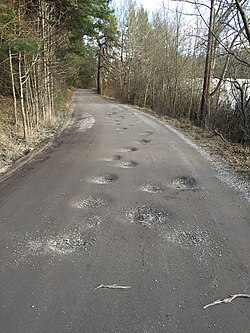


========== QWEN ANALYSIS ==========

{
  "problem": "Multiple potholes on the road surface",
  "civic_category": "Road Maintenance",
  "severity": "High",
  "responsible_department": "Public Works Department",
  "action_required": "Inspect and repair the potholes to ensure road safety and prevent further deterioration of the pavement."
}


In [7]:
# ============================================================
# CIVICLENS — STEP 1
# Upload a real civic problem image and send it to Qwen Vision
# ============================================================

# Import the required libraries
from google.colab import files
from PIL import Image
import base64
import json
import io


# ------------------------------------------------------------
# 1. Upload an image from your computer
# ------------------------------------------------------------

uploaded = files.upload()

# Get the name of the uploaded image
image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)


# ------------------------------------------------------------
# 2. Display the uploaded image
# ------------------------------------------------------------

image = Image.open(image_path)

display(image)


# ------------------------------------------------------------
# 3. Convert the image into Base64
# ------------------------------------------------------------
# Qwen's API can receive an image using a data URL.
# Base64 converts the image into text that we can send
# inside our API request.
# ------------------------------------------------------------

buffer = io.BytesIO()

# Save image as JPEG in memory
image.convert("RGB").save(buffer, format="JPEG")

# Convert image bytes to Base64
image_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

# Create a data URL
image_data_url = f"data:image/jpeg;base64,{image_base64}"


# ------------------------------------------------------------
# 4. Send the image to Qwen
# ------------------------------------------------------------

response = client.chat.completions.create(

    # We will verify/change this model later if necessary
    model="qwen-vl-max",

    messages=[
        {
            "role": "user",

            "content": [

                # Tell Qwen what we want
                {
                    "type": "text",
                    "text": """
You are CivicLens, an AI assistant for identifying
and reporting civic problems.

Analyze this image carefully.

Identify:
1. What problem is visible?
2. Which civic category does it belong to?
3. How severe is the problem?
4. What department should handle it?
5. What action should be taken?

Return your answer as JSON.
"""
                },

                # Send the actual image
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data_url
                    }
                }
            ]
        }
    ]
)


# ------------------------------------------------------------
# 5. Get Qwen's response
# ------------------------------------------------------------

result = response.choices[0].message.content

print("\n========== QWEN ANALYSIS ==========\n")
print(result)

In [8]:
# ============================================================
# CIVICLENS — STEP 2
# Create a structured CivicLens report
# ============================================================

# We will ask Qwen to return a complete civic report.
# The important difference from Step 1 is that we are now
# designing the information that our application will need
# later for the database, dashboard, and AI agent.

import json


# ------------------------------------------------------------
# Send the uploaded image to Qwen again
# ------------------------------------------------------------

response = client.chat.completions.create(

    # Qwen vision model
    model="qwen-vl-max",

    messages=[
        {
            "role": "user",

            "content": [

                # ------------------------------------------------
                # Instructions for Qwen
                # ------------------------------------------------
                {
                    "type": "text",
                    "text": """
You are CivicLens, an AI system that analyzes civic problems.

Analyze the uploaded image and return ONLY valid JSON.

Use exactly these fields:

{
    "problem": "short description of the problem",
    "category": "Road Infrastructure / Waste Management / Water / Electricity / Public Safety / Other",
    "severity": "Low / Medium / High / Critical",
    "priority_score": 0,
    "responsible_department": "department responsible for solving it",
    "description": "detailed explanation of what is visible",
    "risk": "possible risk to people or infrastructure",
    "recommended_action": "what should be done"
}

Priority score must be between 1 and 10.

Do not add extra fields.
Do not use Markdown.
Return JSON only.
"""
                },

                # ------------------------------------------------
                # Send our uploaded image
                # ------------------------------------------------
                {
                    "type": "image_url",
                    "image_url": {
                        "url": image_data_url
                    }
                }
            ]
        }
    ]
)


# ------------------------------------------------------------
# Extract Qwen's response
# ------------------------------------------------------------

result = response.choices[0].message.content


# ------------------------------------------------------------
# Convert JSON text into a Python dictionary
# ------------------------------------------------------------

try:

    report = json.loads(result)

    print("========== CIVICLENS REPORT ==========\n")

    print("Problem:", report["problem"])
    print("Category:", report["category"])
    print("Severity:", report["severity"])
    print("Priority:", report["priority_score"], "/ 10")
    print("Department:", report["responsible_department"])

    print("\nDescription:")
    print(report["description"])

    print("\nRisk:")
    print(report["risk"])

    print("\nRecommended Action:")
    print(report["recommended_action"])


except json.JSONDecodeError:

    print("Qwen did not return valid JSON.")
    print("\nRaw response:")
    print(result)

========== CIVICLENS REPORT ==========

Problem: Potholes on a rural road
Category: Road Infrastructure
Severity: Medium
Priority: 6 / 10
Department: Department of Transportation

Description:
The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.

Risk:
Potholes pose a risk to drivers and cyclists by potentially causing vehicle damage, loss of control, or accidents. They can also create hazards for pedestrians if they are near the edge of the road.

Recommended Action:
Conduct a road inspection and schedule repairs to fill the potholes. Regular maintenance should be implemented to prevent further deterioration.


In [9]:
# ============================================================
# CIVICLENS — STEP 3
# Create our first tool for the Qwen AI Agent
# ============================================================

import json
from datetime import datetime


# ------------------------------------------------------------
# TOOL 1: Save a civic report
# ------------------------------------------------------------
# For now, we will save reports in a Python list.
#
# Later, we will replace this with PostgreSQL.
# ------------------------------------------------------------

civic_reports = []


def save_civic_report(
    problem,
    category,
    severity,
    priority_score,
    responsible_department,
    description,
    risk,
    recommended_action
):
    """
    Save a CivicLens report.

    This is our first real tool that Qwen will eventually
    be able to call.
    """

    report = {
        "report_id": len(civic_reports) + 1,
        "problem": problem,
        "category": category,
        "severity": severity,
        "priority_score": priority_score,
        "responsible_department": responsible_department,
        "description": description,
        "risk": risk,
        "recommended_action": recommended_action,

        # Record when the report was created
        "created_at": datetime.now().isoformat(),

        # New reports start with this status
        "status": "Pending"
    }

    # Add the report to our database-like list
    civic_reports.append(report)

    # Return information to the AI agent
    return {
        "success": True,
        "report_id": report["report_id"],
        "message": "Civic report successfully saved."
    }


# ------------------------------------------------------------
# TEST THE TOOL
# ------------------------------------------------------------

test_result = save_civic_report(
    problem=report["problem"],
    category=report["category"],
    severity=report["severity"],
    priority_score=report["priority_score"],
    responsible_department=report["responsible_department"],
    description=report["description"],
    risk=report["risk"],
    recommended_action=report["recommended_action"]
)

print("========== TOOL RESULT ==========")
print(json.dumps(test_result, indent=2))

print("\n========== SAVED REPORT ==========")
print(json.dumps(civic_reports[0], indent=2))

========== TOOL RESULT ==========
{
  "success": true,
  "report_id": 1,
  "message": "Civic report successfully saved."
}

========== SAVED REPORT ==========
{
  "report_id": 1,
  "problem": "Potholes on a rural road",
  "category": "Road Infrastructure",
  "severity": "Medium",
  "priority_score": 6,
  "responsible_department": "Department of Transportation",
  "description": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.",
  "risk": "Potholes pose a risk to drivers and cyclists by potentially causing vehicle damage, loss of control, or accidents. They can also create hazards for pedestrians if they are near the edge of the road.",
  "recommended_action": "Conduct a road inspection and schedule repairs to fill the potholes. Regular maint

In [10]:
# ============================================================
# CIVICLENS — STEP 4
# Connect our save_civic_report() function to Qwen
# ============================================================

import json


# ------------------------------------------------------------
# 1. Describe our tool to Qwen
# ------------------------------------------------------------
# This does NOT execute the function.
#
# It tells Qwen:
# "You have access to this function."
# ------------------------------------------------------------

tools = [
    {
        "type": "function",

        "function": {
            "name": "save_civic_report",

            "description": """
Save a detected civic problem as a CivicLens report.

Use this function when a civic problem has been analyzed
and should be recorded in the CivicLens system.
""",

            # Tell Qwen exactly what information the function needs
            "parameters": {
                "type": "object",

                "properties": {

                    "problem": {
                        "type": "string",
                        "description": "Short description of the civic problem."
                    },

                    "category": {
                        "type": "string",
                        "description": "Civic problem category."
                    },

                    "severity": {
                        "type": "string",
                        "description": "Severity: Low, Medium, High, or Critical."
                    },

                    "priority_score": {
                        "type": "integer",
                        "description": "Priority score from 1 to 10."
                    },

                    "responsible_department": {
                        "type": "string",
                        "description": "Department responsible for solving the problem."
                    },

                    "description": {
                        "type": "string",
                        "description": "Detailed description of the problem."
                    },

                    "risk": {
                        "type": "string",
                        "description": "Potential risks caused by the problem."
                    },

                    "recommended_action": {
                        "type": "string",
                        "description": "Recommended action to solve the problem."
                    }
                },

                # All of these fields are required
                "required": [
                    "problem",
                    "category",
                    "severity",
                    "priority_score",
                    "responsible_department",
                    "description",
                    "risk",
                    "recommended_action"
                ]
            }
        }
    }
]


# ------------------------------------------------------------
# 2. Give Qwen the civic report we already created
# ------------------------------------------------------------

report_text = json.dumps(report)


# ------------------------------------------------------------
# 3. Ask Qwen to decide whether the report should be saved
# ------------------------------------------------------------

agent_response = client.chat.completions.create(

    # Use the Qwen model that is working in your notebook
    model="qwen-plus",

    messages=[
        {
            "role": "system",
            "content": """
You are CivicLens, an AI civic-reporting agent.

Your job is to analyze civic problems and decide when they
should be saved into the CivicLens reporting system.

When a report should be saved, use the save_civic_report tool.
"""
        },

        {
            "role": "user",
            "content": f"""
Here is the civic problem detected by the vision system:

{report_text}

Save this civic report to the CivicLens system.
"""
        }
    ],

    # Give Qwen access to our function
    tools=tools,

    # Let Qwen decide whether to call the function
    tool_choice="auto"
)


# ------------------------------------------------------------
# 4. Inspect Qwen's decision
# ------------------------------------------------------------

message = agent_response.choices[0].message

print("========== QWEN AGENT RESPONSE ==========\n")

print("Text response:")
print(message.content)

print("\nTool calls:")

if message.tool_calls:

    for tool_call in message.tool_calls:

        print("\nTool:", tool_call.function.name)

        print("Arguments:")
        print(tool_call.function.arguments)

else:

    print("Qwen did not call a tool.")

========== QWEN AGENT RESPONSE ==========

Text response:


Tool calls:

Tool: save_civic_report
Arguments:
{"problem": "Potholes on a rural road", "category": "Road Infrastructure", "severity": "Medium", "priority_score": 6, "responsible_department": "Department of Transportation", "description": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.", "risk": "Potholes pose a risk to drivers and cyclists by potentially causing vehicle damage, loss of control, or accidents. They can also create hazards for pedestrians if they are near the edge of the road.", "recommended_action": "Conduct a road inspection and schedule repairs to fill the potholes. Regular maintenance should be implemented to prevent further deterioration."}


In [11]:
# ============================================================
# CIVICLENS — STEP 5
# Execute the tool selected by Qwen
# ============================================================

# ------------------------------------------------------------
# 1. Check whether Qwen requested a tool
# ------------------------------------------------------------

if message.tool_calls:

    # We can have multiple tool calls, so we use a loop
    for tool_call in message.tool_calls:

        # Get the name of the function Qwen selected
        function_name = tool_call.function.name

        # Get the arguments Qwen generated
        arguments = json.loads(tool_call.function.arguments)

        print("Qwen selected:", function_name)

        print("\nArguments generated by Qwen:")
        print(json.dumps(arguments, indent=2))


        # ----------------------------------------------------
        # 2. Execute the correct Python function
        # ----------------------------------------------------

        if function_name == "save_civic_report":

            tool_result = save_civic_report(**arguments)

        else:

            tool_result = {
                "success": False,
                "message": f"Unknown tool: {function_name}"
            }


        # ----------------------------------------------------
        # 3. Display the result returned by our tool
        # ----------------------------------------------------

        print("\n========== TOOL EXECUTION RESULT ==========")

        print(json.dumps(tool_result, indent=2))


else:

    print("Qwen did not request any tool.")

Qwen selected: save_civic_report

Arguments generated by Qwen:
{
  "problem": "Potholes on a rural road",
  "category": "Road Infrastructure",
  "severity": "Medium",
  "priority_score": 6,
  "responsible_department": "Department of Transportation",
  "description": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.",
  "risk": "Potholes pose a risk to drivers and cyclists by potentially causing vehicle damage, loss of control, or accidents. They can also create hazards for pedestrians if they are near the edge of the road.",
  "recommended_action": "Conduct a road inspection and schedule repairs to fill the potholes. Regular maintenance should be implemented to prevent further deterioration."
}

========== TOOL EXECUTION RESULT ==========
{
 

In [12]:
# ============================================================
# CIVICLENS — STEP 6
# Complete Qwen's Agent Loop
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
# The variable `message` came from Step 4.
# The variable `tool_result` came from Step 5.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Create the conversation history
# ------------------------------------------------------------
# We give Qwen:
# - The original system instruction
# - The user's request
# - Qwen's tool-call message
# ------------------------------------------------------------

messages = [
    {
        "role": "system",
        "content": """
You are CivicLens, an AI civic-reporting agent.

You analyze civic problems and help users report them.
When a report is successfully saved, clearly tell the
user that the report was created.
"""
    },

    {
        "role": "user",
        "content": f"""
The following civic problem was detected:

{json.dumps(report, indent=2)}

Save this report and tell me the result.
"""
    },

    # This is Qwen's previous response containing
    # the request to call our tool.
    message
]


# ------------------------------------------------------------
# 2. Add the tool result to the conversation
# ------------------------------------------------------------
# Qwen needs to know what happened after its tool call.
# ------------------------------------------------------------

for tool_call in message.tool_calls:

    messages.append(
        {
            "role": "tool",

            # Tell Qwen which tool produced this result
            "tool_call_id": tool_call.id,

            # Give Qwen the result from Python
            "content": json.dumps(tool_result)
        }
    )


# ------------------------------------------------------------
# 3. Ask Qwen for the final response
# ------------------------------------------------------------

final_response = client.chat.completions.create(

    # Use the same text model that worked in Step 4
    model="qwen-plus",

    messages=messages,

    # Qwen still has access to our tool
    tools=tools,

    # We let Qwen decide what to do
    tool_choice="auto"
)


# ------------------------------------------------------------
# 4. Display the final answer
# ------------------------------------------------------------

final_message = final_response.choices[0].message

print("========== CIVICLENS FINAL RESPONSE ==========\n")

print(final_message.content)

========== CIVICLENS FINAL RESPONSE ==========

The civic report for "Potholes on a rural road" has been successfully created and saved with report ID **2**.


In [13]:
# ============================================================
# CIVICLENS — STEP 7
# Add location information to our civic report
# ============================================================

# ------------------------------------------------------------
# Why do we need location?
#
# A civic problem without a location is difficult to act on.
#
# Example:
#
# "There is a pothole."
#
# ❌ Not very useful.
#
# "There is a pothole at latitude X, longitude Y."
#
# ✅ Much more useful.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. For now, create a test location
# ------------------------------------------------------------
# Later, this will come from the user's device GPS.
# ------------------------------------------------------------

location = {
    "latitude": 34.0151,
    "longitude": 71.5249
}


# ------------------------------------------------------------
# 2. Add the location to our report
# ------------------------------------------------------------

report["location"] = location


# ------------------------------------------------------------
# 3. Display the updated report
# ------------------------------------------------------------

print("========== CIVICLENS REPORT WITH LOCATION ==========\n")

print(json.dumps(report, indent=2))

========== CIVICLENS REPORT WITH LOCATION ==========

{
  "problem": "Potholes on a rural road",
  "category": "Road Infrastructure",
  "severity": "Medium",
  "priority_score": 6,
  "responsible_department": "Department of Transportation",
  "description": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.",
  "risk": "Potholes pose a risk to drivers and cyclists by potentially causing vehicle damage, loss of control, or accidents. They can also create hazards for pedestrians if they are near the edge of the road.",
  "recommended_action": "Conduct a road inspection and schedule repairs to fill the potholes. Regular maintenance should be implemented to prevent further deterioration.",
  "location": {
    "latitude": 34.0151,
    "longitude": 

In [14]:
# ============================================================
# CIVICLENS — STEP 8
# AI Priority Analysis Tool
# ============================================================

import json


# ------------------------------------------------------------
# TOOL: Calculate civic priority
# ------------------------------------------------------------
# This tool receives information about a civic problem
# and returns a priority score and explanation.
#
# Later, we can connect this to real location/map data.
# ------------------------------------------------------------

def calculate_priority(
    severity,
    risk,
    category,
    location_context="Unknown"
):
    """
    Calculate the priority of a civic problem.

    This is a simple prototype.
    Later, we can make this much more sophisticated.
    """

    # Start with a base score based on severity
    severity_scores = {
        "Low": 2,
        "Medium": 5,
        "High": 8,
        "Critical": 10
    }

    base_score = severity_scores.get(severity, 5)

    # --------------------------------------------------------
    # Increase priority when the problem involves safety risk
    # --------------------------------------------------------

    risk_keywords = [
        "accident",
        "injury",
        "danger",
        "hazard",
        "vehicle",
        "pedestrian",
        "cyclist"
    ]

    risk_lower = risk.lower()

    safety_risk = any(
        keyword in risk_lower
        for keyword in risk_keywords
    )

    if safety_risk:
        base_score += 1


    # --------------------------------------------------------
    # Keep score between 1 and 10
    # --------------------------------------------------------

    final_score = min(base_score, 10)


    # --------------------------------------------------------
    # Create an explanation
    # --------------------------------------------------------

    if final_score >= 9:
        priority_level = "Critical"

    elif final_score >= 7:
        priority_level = "High"

    elif final_score >= 4:
        priority_level = "Medium"

    else:
        priority_level = "Low"


    explanation = (
        f"The problem is classified as {severity} severity. "
        f"The reported risks indicate a potential safety concern. "
        f"Location context: {location_context}."
    )


    # --------------------------------------------------------
    # Return structured information
    # --------------------------------------------------------

    return {
        "priority_score": final_score,
        "priority_level": priority_level,
        "safety_risk_detected": safety_risk,
        "reason": explanation
    }


# ------------------------------------------------------------
# TEST THE TOOL WITH OUR CURRENT REPORT
# ------------------------------------------------------------

priority_result = calculate_priority(
    severity=report["severity"],
    risk=report["risk"],
    category=report["category"],
    location_context="Urban road area"
)


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

print("========== CIVICLENS PRIORITY ANALYSIS ==========\n")

print(
    json.dumps(
        priority_result,
        indent=2
    )
)

========== CIVICLENS PRIORITY ANALYSIS ==========

{
  "priority_score": 6,
  "priority_level": "Medium",
  "safety_risk_detected": true,
  "reason": "The problem is classified as Medium severity. The reported risks indicate a potential safety concern. Location context: Urban road area."
}


In [15]:
# ============================================================
# CIVICLENS — STEP 9
# Create a location tool
# ============================================================

import json


# ------------------------------------------------------------
# This function represents a real GPS/location service.
#
# For now we use a sample location.
#
# Later:
# Browser GPS → latitude/longitude → this function
# ------------------------------------------------------------

def get_location():

    # Sample coordinates
    location = {
        "latitude": 34.0151,
        "longitude": 71.5249
    }

    return {
        "success": True,
        "location": location,
        "message": "Current location retrieved successfully."
    }


# ------------------------------------------------------------
# Test the location tool
# ------------------------------------------------------------

location_result = get_location()


print("========== LOCATION TOOL RESULT ==========\n")

print(json.dumps(location_result, indent=2))

========== LOCATION TOOL RESULT ==========

{
  "success": true,
  "location": {
    "latitude": 34.0151,
    "longitude": 71.5249
  },
  "message": "Current location retrieved successfully."
}


In [16]:
# ============================================================
# CIVICLENS — STEP 10
# Find previously reported problems near a location
# ============================================================

import math
import json


# ------------------------------------------------------------
# Calculate distance between two GPS coordinates
# ------------------------------------------------------------
# We use the Haversine formula because latitude/longitude
# coordinates are measured on the Earth's surface.
# ------------------------------------------------------------

def calculate_distance(lat1, lon1, lat2, lon2):

    # Convert degrees to radians
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)

    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    # Differences between the coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.asin(math.sqrt(a))

    # Earth's approximate radius in kilometers
    earth_radius_km = 6371

    return earth_radius_km * c


# ------------------------------------------------------------
# TOOL: Find nearby civic reports
# ------------------------------------------------------------

def find_nearby_reports(latitude, longitude, radius_km=1):

    nearby_reports = []

    # Check every report that we have saved
    for saved_report in civic_reports:

        # Skip reports without location
        if "location" not in saved_report:
            continue

        report_lat = saved_report["location"]["latitude"]
        report_lon = saved_report["location"]["longitude"]

        # Calculate distance
        distance = calculate_distance(
            latitude,
            longitude,
            report_lat,
            report_lon
        )

        # Keep reports inside our selected radius
        if distance <= radius_km:

            nearby_reports.append({
                "report_id": saved_report["report_id"],
                "problem": saved_report["problem"],
                "category": saved_report["category"],
                "severity": saved_report["severity"],
                "priority_score": saved_report["priority_score"],
                "distance_km": round(distance, 3),
                "status": saved_report["status"]
            })

    return {
        "success": True,
        "number_of_nearby_reports": len(nearby_reports),
        "reports": nearby_reports
    }


# ------------------------------------------------------------
# TEST THE TOOL
# ------------------------------------------------------------

location_result = get_location()

current_location = location_result["location"]

nearby_result = find_nearby_reports(
    latitude=current_location["latitude"],
    longitude=current_location["longitude"],
    radius_km=1
)


print("========== NEARBY REPORT SEARCH ==========\n")

print(json.dumps(nearby_result, indent=2))

========== NEARBY REPORT SEARCH ==========

{
  "success": true,
  "number_of_nearby_reports": 0,
  "reports": []
}


In [17]:
# ============================================================
# CIVICLENS — STEP 11
# Save civic reports WITH their location
# ============================================================

def save_civic_report(
    problem,
    category,
    severity,
    priority_score,
    responsible_department,
    description,
    risk,
    recommended_action,
    latitude,
    longitude
):
    """
    Save a CivicLens report together with its GPS location.
    """

    # Create the report
    new_report = {
        "report_id": len(civic_reports) + 1,

        "problem": problem,
        "category": category,
        "severity": severity,
        "priority_score": priority_score,
        "responsible_department": responsible_department,

        "description": description,
        "risk": risk,
        "recommended_action": recommended_action,

        # ----------------------------------------------------
        # Store the GPS coordinates
        # ----------------------------------------------------
        "location": {
            "latitude": latitude,
            "longitude": longitude
        },

        # Report status
        "status": "Pending",

        # Creation time
        "created_at": datetime.now().isoformat()
    }

    # Save the report
    civic_reports.append(new_report)

    # Return confirmation
    return {
        "success": True,
        "report_id": new_report["report_id"],
        "message": "Civic report successfully saved."
    }

In [18]:
# ============================================================
# CIVICLENS — STEP 12
# Save the current report with its location
# ============================================================

# Get the current location
location_result = get_location()

current_location = location_result["location"]


# Save the report
save_result = save_civic_report(
    problem=report["problem"],
    category=report["category"],
    severity=report["severity"],
    priority_score=report["priority_score"],
    responsible_department=report["responsible_department"],
    description=report["description"],
    risk=report["risk"],
    recommended_action=report["recommended_action"],

    # Add GPS coordinates
    latitude=current_location["latitude"],
    longitude=current_location["longitude"]
)


print("========== SAVE RESULT ==========\n")

print(json.dumps(save_result, indent=2))


# Show the newly saved report
print("\n========== SAVED REPORT ==========\n")

print(json.dumps(civic_reports[-1], indent=2))

========== SAVE RESULT ==========

{
  "success": true,
  "report_id": 3,
  "message": "Civic report successfully saved."
}

========== SAVED REPORT ==========

{
  "report_id": 3,
  "problem": "Potholes on a rural road",
  "category": "Road Infrastructure",
  "severity": "Medium",
  "priority_score": 6,
  "responsible_department": "Department of Transportation",
  "description": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.",
  "risk": "Potholes pose a risk to drivers and cyclists by potentially causing vehicle damage, loss of control, or accidents. They can also create hazards for pedestrians if they are near the edge of the road.",
  "recommended_action": "Conduct a road inspection and schedule repairs to fill the potholes. Regular mai

In [19]:
# ============================================================
# CIVICLENS — STEP 13
# Test nearby report detection again
# ============================================================

location_result = get_location()

current_location = location_result["location"]

nearby_result = find_nearby_reports(
    latitude=current_location["latitude"],
    longitude=current_location["longitude"],
    radius_km=1
)

print("========== NEARBY REPORT SEARCH ==========\n")

print(json.dumps(nearby_result, indent=2))

========== NEARBY REPORT SEARCH ==========

{
  "success": true,
  "number_of_nearby_reports": 1,
  "reports": [
    {
      "report_id": 3,
      "problem": "Potholes on a rural road",
      "category": "Road Infrastructure",
      "severity": "Medium",
      "priority_score": 6,
      "distance_km": 0.0,
      "status": "Pending"
    }
  ]
}


In [20]:
# ============================================================
# CIVICLENS — STEP 14
# Create the complete Qwen CivicLens Agent
# ============================================================

# We already have these Python functions:
#
# get_location()
# find_nearby_reports()
# calculate_priority()
# save_civic_report()
#
# Now we describe them to Qwen as available tools.
# ============================================================


# ------------------------------------------------------------
# 1. Define the tools available to Qwen
# ------------------------------------------------------------

civic_tools = [

    # ========================================================
    # TOOL 1 — Get user's location
    # ========================================================

    {
        "type": "function",

        "function": {
            "name": "get_location",

            "description": """
Get the user's current GPS location.
Use this when the civic report needs location information.
""",

            "parameters": {
                "type": "object",
                "properties": {}
            }
        }
    },


    # ========================================================
    # TOOL 2 — Find nearby reports
    # ========================================================

    {
        "type": "function",

        "function": {
            "name": "find_nearby_reports",

            "description": """
Find previously reported civic problems near a given
latitude and longitude.

Use this before creating a new report when you want to
check whether a similar problem has already been reported.
""",

            "parameters": {
                "type": "object",

                "properties": {

                    "latitude": {
                        "type": "number",
                        "description": "GPS latitude."
                    },

                    "longitude": {
                        "type": "number",
                        "description": "GPS longitude."
                    },

                    "radius_km": {
                        "type": "number",
                        "description": "Search radius in kilometers."
                    }
                },

                "required": [
                    "latitude",
                    "longitude"
                ]
            }
        }
    },


    # ========================================================
    # TOOL 3 — Save civic report
    # ========================================================

    {
        "type": "function",

        "function": {
            "name": "save_civic_report",

            "description": """
Save a new civic problem report into the CivicLens system.
Use this after analyzing the civic problem.
""",

            "parameters": {
                "type": "object",

                "properties": {

                    "problem": {
                        "type": "string"
                    },

                    "category": {
                        "type": "string"
                    },

                    "severity": {
                        "type": "string"
                    },

                    "priority_score": {
                        "type": "integer"
                    },

                    "responsible_department": {
                        "type": "string"
                    },

                    "description": {
                        "type": "string"
                    },

                    "risk": {
                        "type": "string"
                    },

                    "recommended_action": {
                        "type": "string"
                    },

                    "latitude": {
                        "type": "number"
                    },

                    "longitude": {
                        "type": "number"
                    }
                },

                "required": [
                    "problem",
                    "category",
                    "severity",
                    "priority_score",
                    "responsible_department",
                    "description",
                    "risk",
                    "recommended_action",
                    "latitude",
                    "longitude"
                ]
            }
        }
    }
]


print("✅ CivicLens tools registered:")
print("1. get_location")
print("2. find_nearby_reports")
print("3. save_civic_report")

✅ CivicLens tools registered:
1. get_location
2. find_nearby_reports
3. save_civic_report


In [21]:
# ============================================================
# CIVICLENS — STEP 15
# Ask Qwen to operate as a CivicLens agent
# ============================================================

agent_messages = [

    {
        "role": "system",

        "content": """
You are CivicLens, an AI civic problem reporting agent.

Your responsibilities are:

1. Understand the civic problem.
2. Determine its severity and priority.
3. Obtain the user's location when necessary.
4. Check for nearby existing reports.
5. Save the report when appropriate.
6. Clearly explain the result to the user.

You have access to civic tools.

Use tools when they are useful.
Do not invent information that can be obtained from a tool.
"""
    },

    {
        "role": "user",

        "content": f"""
Process this civic report:

{json.dumps(report, indent=2)}

Please determine what actions should be taken.
"""
    }
]


# ------------------------------------------------------------
# Ask Qwen to decide which tools it needs
# ------------------------------------------------------------

agent_response = client.chat.completions.create(

    model="qwen-plus",

    messages=agent_messages,

    tools=civic_tools,

    tool_choice="auto"
)


agent_message = agent_response.choices[0].message


# ------------------------------------------------------------
# Show Qwen's decision
# ------------------------------------------------------------

print("========== CIVICLENS AGENT DECISION ==========\n")

print("Text:")
print(agent_message.content)

print("\nTool calls:")

if agent_message.tool_calls:

    for tool_call in agent_message.tool_calls:

        print("\nTool:", tool_call.function.name)

        print(
            "Arguments:",
            tool_call.function.arguments
        )

else:

    print("No tool calls.")

========== CIVICLENS AGENT DECISION ==========

Text:
I'll process this civic report about potholes on a rural road.

First, let me check if there are any nearby existing reports for this location to avoid duplication:



Tool calls:

Tool: find_nearby_reports
Arguments: {"latitude": 34.0151, "longitude": 71.5249, "radius_km": 1}


In [22]:
# ============================================================
# CIVICLENS — STEP 16
# Execute Qwen's requested tools and return results to Qwen
# ============================================================

# ------------------------------------------------------------
# This function takes a tool call generated by Qwen
# and executes the corresponding Python function.
# ------------------------------------------------------------
# ============================================================
# CIVICLENS — STEP 20.1
# Updated Tool Executor
# ============================================================

def execute_civic_tool(tool_call):

    # --------------------------------------------------------
    # Get the tool selected by Qwen
    # --------------------------------------------------------

    function_name = tool_call.function.name

    # Convert JSON arguments into Python dictionary
    arguments = json.loads(
        tool_call.function.arguments
    )

    print(f"\n🔧 Qwen requested tool: {function_name}")

    print("\nArguments:")
    print(
        json.dumps(
            arguments,
            indent=2
        )
    )


    # ========================================================
    # TOOL 1 — Get location
    # ========================================================

    if function_name == "get_location":

        result = get_location()


    # ========================================================
    # TOOL 2 — Find nearby reports
    # ========================================================

    elif function_name == "find_nearby_reports":

        result = find_nearby_reports(
            latitude=arguments["latitude"],
            longitude=arguments["longitude"],
            radius_km=arguments.get(
                "radius_km",
                1
            )
        )


    # ========================================================
    # TOOL 3 — Save civic report
    # ========================================================

    elif function_name == "save_civic_report":

        result = save_civic_report(
            **arguments
        )


    # ========================================================
    # TOOL 4 — Update civic report
    # ========================================================

    elif function_name == "update_civic_report":

        result = update_civic_report(
            **arguments
        )


    # ========================================================
    # Unknown tool
    # ========================================================

    else:

        result = {
            "success": False,
            "error": f"Unknown tool: {function_name}"
        }


    # --------------------------------------------------------
    # Display tool result
    # --------------------------------------------------------

    print("\n🔧 Tool result:")

    print(
        json.dumps(
            result,
            indent=2
        )
    )

    return result

In [23]:
# ============================================================
# CIVICLENS — STEP 17 FIX
# Execute Qwen's tool calls and continue the conversation
# ============================================================

# ------------------------------------------------------------
# Make sure Qwen actually requested a tool
# ------------------------------------------------------------

if not agent_message.tool_calls:

    print("Qwen did not request any tool.")
    print("\nFinal response:")
    print(agent_message.content)

else:

    # --------------------------------------------------------
    # Create tool_results HERE
    # This fixes:
    # NameError: name 'tool_results' is not defined
    # --------------------------------------------------------

    tool_results = []

    # --------------------------------------------------------
    # Execute every tool requested by Qwen
    # --------------------------------------------------------

    for tool_call in agent_message.tool_calls:

        result = execute_civic_tool(tool_call)

        tool_results.append({
            "tool_call_id": tool_call.id,
            "result": result
        })

    # --------------------------------------------------------
    # Add Qwen's tool-call message to the conversation
    # --------------------------------------------------------

    agent_messages.append(agent_message)

    # --------------------------------------------------------
    # Send each tool result back to Qwen
    # --------------------------------------------------------

    for item in tool_results:

        agent_messages.append({
            "role": "tool",
            "tool_call_id": item["tool_call_id"],
            "content": json.dumps(item["result"])
        })

    # --------------------------------------------------------
    # Ask Qwen what to do next
    # --------------------------------------------------------

    next_response = client.chat.completions.create(
        model="qwen-plus",
        messages=agent_messages,
        tools=civic_tools,
        tool_choice="auto"
    )

    next_message = next_response.choices[0].message

    # --------------------------------------------------------
    # Display the next decision
    # --------------------------------------------------------

    print("\n========== QWEN NEXT DECISION ==========\n")

    print("Text:")
    print(next_message.content)

    print("\nTool calls:")

    if next_message.tool_calls:

        for tool_call in next_message.tool_calls:

            print(
                "Tool:",
                tool_call.function.name
            )

            print(
                "Arguments:",
                tool_call.function.arguments
            )

    else:

        print("Qwen decided that no more tools are needed.")


🔧 Qwen requested tool: find_nearby_reports

Arguments:
{
  "latitude": 34.0151,
  "longitude": 71.5249,
  "radius_km": 1
}

🔧 Tool result:
{
  "success": true,
  "number_of_nearby_reports": 1,
  "reports": [
    {
      "report_id": 3,
      "problem": "Potholes on a rural road",
      "category": "Road Infrastructure",
      "severity": "Medium",
      "priority_score": 6,
      "distance_km": 0.0,
      "status": "Pending"
    }
  ]
}

========== QWEN NEXT DECISION ==========

Text:
I found that there is already one existing report for potholes on this rural road at the same location (distance: 0.0 km), with the same problem description, severity level, and priority score. This report is currently in "Pending" status.

Since this appears to be a duplicate report for the same issue at the exact same location, I won't create a new report. Instead, I'll inform the user about the existing report and suggest they can follow up on the pending report.

The existing report has been properly

In [24]:
# ============================================================
# CIVICLENS — CELL 18
# Update an existing civic report
# ============================================================

def update_civic_report(
    report_id,
    additional_information,
    new_severity=None,
    new_priority_score=None
):
    """
    Update an existing CivicLens report with new information.
    """

    # Find the existing report
    for saved_report in civic_reports:

        if saved_report["report_id"] == report_id:

            # Add the new information
            saved_report["additional_information"] = (
                additional_information
            )

            # Update severity if provided
            if new_severity is not None:
                saved_report["severity"] = new_severity

            # Update priority if provided
            if new_priority_score is not None:
                saved_report["priority_score"] = new_priority_score

            return {
                "success": True,
                "report_id": report_id,
                "message": "Civic report successfully updated."
            }

    # Report does not exist
    return {
        "success": False,
        "error": f"Report {report_id} not found."
    }


print("✅ update_civic_report() is ready.")

✅ update_civic_report() is ready.


In [25]:
# ============================================================
# CIVICLENS — STEP 19
# Register update_civic_report with Qwen
# ============================================================

civic_tools.append(
    {
        "type": "function",

        "function": {
            "name": "update_civic_report",

            "description": """
Update an existing civic report when a new submission
appears to concern the same civic problem but contains
additional useful information.

Use this instead of creating a duplicate report when
new information should be attached to an existing report.
""",

            "parameters": {
                "type": "object",

                "properties": {

                    "report_id": {
                        "type": "integer",
                        "description": "ID of the existing report."
                    },

                    "additional_information": {
                        "type": "string",
                        "description": "New information from the latest report."
                    },

                    "new_severity": {
                        "type": "string",
                        "description": "Updated severity if appropriate."
                    },

                    "new_priority_score": {
                        "type": "integer",
                        "description": "Updated priority from 1 to 10 if appropriate."
                    }
                },

                "required": [
                    "report_id",
                    "additional_information"
                ]
            }
        }
    }
)

print("✅ update_civic_report added to Qwen's tools.")

✅ update_civic_report added to Qwen's tools.


In [26]:
# ============================================================
# CIVICLENS — STEP 20
# Automatic Multi-Tool Qwen Agent Loop
# ============================================================

def run_civiclens_agent(report):

    # --------------------------------------------------------
    # 1. Initial conversation
    # --------------------------------------------------------

    messages = [

        {
            "role": "system",
            "content": """
You are CivicLens, an AI civic-reporting agent.

Your job is to process civic problems detected from images.

Follow this general process:

1. Understand the civic problem.
2. Use the location when needed.
3. Check for nearby existing reports.
4. If a matching report already exists:
   - Do not create an unnecessary duplicate.
   - If the new information adds value, update the existing report.
5. If there is no matching report, save a new report.
6. Give the user a clear final response.

Important:
- Use tools when appropriate.
- Do not invent tool results.
- Do not claim a report was saved unless the save tool
  actually succeeds.
- If an existing report is found, use its real report ID.
"""
        },

        {
            "role": "user",
            "content": f"""
Process this CivicLens report:

{json.dumps(report, indent=2)}
"""
        }
    ]


    # --------------------------------------------------------
    # 2. Maximum number of agent iterations
    # --------------------------------------------------------
    # This prevents an accidental infinite loop.
    # --------------------------------------------------------

    max_iterations = 5


    for iteration in range(max_iterations):

        print(
            f"\n========== AGENT ITERATION {iteration + 1} =========="
        )


        # ----------------------------------------------------
        # Ask Qwen what to do
        # ----------------------------------------------------

        response = client.chat.completions.create(

            model="qwen-plus",

            messages=messages,

            tools=civic_tools,

            tool_choice="auto"
        )


        assistant_message = response.choices[0].message


        # ----------------------------------------------------
        # Add Qwen's response to conversation history
        # ----------------------------------------------------

        messages.append(assistant_message)


        # ----------------------------------------------------
        # If Qwen doesn't request a tool,
        # the agent has finished.
        # ----------------------------------------------------

        if not assistant_message.tool_calls:

            print("\n========== CIVICLENS FINAL RESPONSE ==========\n")

            print(assistant_message.content)

            return assistant_message.content


        # ----------------------------------------------------
        # Execute every tool requested by Qwen
        # ----------------------------------------------------

        for tool_call in assistant_message.tool_calls:

            result = execute_civic_tool(tool_call)


            # ------------------------------------------------
            # Send the tool result back to Qwen
            # ------------------------------------------------

            messages.append(
                {
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": json.dumps(result)
                }
            )


    # --------------------------------------------------------
    # Safety fallback if Qwen never finishes
    # --------------------------------------------------------

    print("\n⚠️ Agent reached maximum iterations.")

    return "CivicLens could not complete the request."


# ============================================================
# TEST THE COMPLETE AGENT
# ============================================================

final_result = run_civiclens_agent(report)


========== AGENT ITERATION 1 ==========

🔧 Qwen requested tool: find_nearby_reports

Arguments:
{
  "latitude": 34.0151,
  "longitude": 71.5249,
  "radius_km": 1
}

🔧 Tool result:
{
  "success": true,
  "number_of_nearby_reports": 1,
  "reports": [
    {
      "report_id": 3,
      "problem": "Potholes on a rural road",
      "category": "Road Infrastructure",
      "severity": "Medium",
      "priority_score": 6,
      "distance_km": 0.0,
      "status": "Pending"
    }
  ]
}

========== AGENT ITERATION 2 ==========

🔧 Qwen requested tool: update_civic_report

Arguments:
{
  "report_id": 3,
  "additional_information": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.",
  "new_priority_score": 6,
  "new_severity": "Medium"
}

🔧 Tool result:


In [27]:
# ============================================================
# CIVICLENS — CELL 21
# Final integrated CivicLens test
# ============================================================

# IMPORTANT:
# This cell uses the report already produced by Qwen Vision.
# It does NOT create another report manually.

final_result = run_civiclens_agent(report)

print("\n========== CIVICLENS RESULT ==========\n")
print(final_result)


========== AGENT ITERATION 1 ==========

🔧 Qwen requested tool: find_nearby_reports

Arguments:
{
  "latitude": 34.0151,
  "longitude": 71.5249,
  "radius_km": 1
}

🔧 Tool result:
{
  "success": true,
  "number_of_nearby_reports": 1,
  "reports": [
    {
      "report_id": 3,
      "problem": "Potholes on a rural road",
      "category": "Road Infrastructure",
      "severity": "Medium",
      "priority_score": 6,
      "distance_km": 0.0,
      "status": "Pending"
    }
  ]
}

========== AGENT ITERATION 2 ==========

🔧 Qwen requested tool: update_civic_report

Arguments:
{
  "report_id": 3,
  "additional_information": "The image shows a paved road in a forested area with multiple potholes scattered across the surface. The potholes vary in size and depth, some appearing to be filled with debris or water. The road is narrow and appears to be used for light traffic, possibly in a residential or recreational area.",
  "new_priority_score": 6,
  "new_severity": "Medium"
}

🔧 Tool result:


In [28]:
# ============================================================
# CIVICLENS — CELL 22
# Validate tool results
# ============================================================

def validate_tool_result(result):

    # Check whether the tool succeeded
    if not result.get("success", False):

        print("⚠️ TOOL FAILED")
        print(json.dumps(result, indent=2))

        return False

    return True


print("✅ Tool-result validation is ready.")

✅ Tool-result validation is ready.


In [34]:
# ============================================================
# CIVICLENS — CELL 23
# Test CivicLens with a new image
# ============================================================

from google.colab import files

# Upload another civic-problem image
uploaded = files.upload()

# Get uploaded filename
image_path = next(iter(uploaded))

print("Uploaded image:", image_path)

# ------------------------------------------------------------
# Run your existing Qwen Vision analysis
# ------------------------------------------------------------
# IMPORTANT:
# Use the SAME vision-analysis function/cell that already
# produced your QWEN ANALYSIS JSON.
#
# If your existing code stores the result in report,
# keep using that result here.
# ------------------------------------------------------------

# ============================================================
# CIVICLENS — VISION ANALYSIS
# Analyze the CURRENT uploaded image with Qwen Vision
# ============================================================

import base64
import json

# ------------------------------------------------------------
# Make sure image_path points to the image you just uploaded
# ------------------------------------------------------------

print("Analyzing image:", image_path)

# Read the CURRENT image from disk
with open(image_path, "rb") as f:
    image_bytes = f.read()

# Convert image to Base64
image_base64 = base64.b64encode(image_bytes).decode("utf-8")

# Determine image type
if image_path.lower().endswith(".png"):
    mime_type = "image/png"
elif image_path.lower().endswith(".webp"):
    mime_type = "image/webp"
else:
    mime_type = "image/jpeg"


# ------------------------------------------------------------
# Strong vision prompt
# ------------------------------------------------------------

vision_prompt = """
You are CivicLens, a civic infrastructure image-analysis AI.

Analyze ONLY the image provided in this request.

IMPORTANT:
- Do NOT rely on any previous image.
- Do NOT reuse a previous analysis.
- Identify what is ACTUALLY visible in this image.
- Do not assume that every road problem is a pothole.
- Carefully distinguish between potholes, street lights,
  traffic signals, signs, garbage, sidewalks, buildings,
  drainage, vehicles, and other civic infrastructure.

Return ONLY valid JSON.

Use exactly these fields:

{
  "problem": "...",
  "category": "...",
  "severity": "Low | Medium | High | Critical",
  "priority_score": 1,
  "responsible_department": "...",
  "description": "...",
  "risk": "...",
  "recommended_action": "..."
}

The priority_score must be an integer from 1 to 10.

Base your answer only on visible evidence in the image.
"""


# ------------------------------------------------------------
# Send CURRENT image to Qwen Vision
# ------------------------------------------------------------

vision_response = client.chat.completions.create(

    model="qwen-vl-max",

    messages=[
        {
            "role": "user",

            "content": [

                {
                    "type": "text",
                    "text": vision_prompt
                },

                {
                    "type": "image_url",
                    "image_url": {
                        "url": (
                            f"data:{mime_type};base64,"
                            f"{image_base64}"
                        )
                    }
                }

            ]
        }
    ]
)


# ------------------------------------------------------------
# Get Qwen response
# ------------------------------------------------------------

vision_text = vision_response.choices[0].message.content

print("\n========== QWEN RAW VISION RESPONSE ==========\n")
print(vision_text)


# ------------------------------------------------------------
# Convert JSON response into Python dictionary
# ------------------------------------------------------------

try:

    report = json.loads(vision_text)

except json.JSONDecodeError:

    print("\n⚠️ Qwen did not return pure JSON.")

    # Try extracting JSON from markdown/code fences
    cleaned = (
        vision_text
        .replace("```json", "")
        .replace("```", "")
        .strip()
    )

    report = json.loads(cleaned)


print("\n========== QWEN CIVIC ANALYSIS ==========\n")
print(
    json.dumps(
        report,
        indent=2
    )
)

Saving garbage1.jpg to garbage1.jpg
Uploaded image: garbage1.jpg
Analyzing image: garbage1.jpg

========== QWEN RAW VISION RESPONSE ==========

{
  "problem": "Garbage accumulation",
  "category": "Waste Management",
  "severity": "Critical",
  "priority_score": 10,
  "responsible_department": "Municipal Waste Management Department",
  "description": "A large pile of uncollected garbage, including plastic bags and debris, is accumulated along the roadside, obstructing part of the road and creating a hazardous environment.",
  "risk": "High risk of environmental pollution, health hazards due to open waste, potential for fire, and obstruction to traffic flow.",
  "recommended_action": "Immediate cleanup operation by municipal authorities, followed by enhanced waste collection schedules and public awareness campaigns on proper waste disposal."
}

========== QWEN CIVIC ANALYSIS ==========

{
  "problem": "Garbage accumulation",
  "category": "Waste Management",
  "severity": "Critical",
  

In [35]:
# ============================================================
# CIVICLENS — CELL 24
# Test NEW civic problem vs existing report
# ============================================================

print("\n========== CIVICLENS AGENT TEST ==========\n")

# Send the NEW vision analysis to the Qwen agent
final_result = run_civiclens_agent(report)

print("\n========== CIVICLENS FINAL RESULT ==========\n")
print(final_result)


========== CIVICLENS AGENT TEST ==========


========== AGENT ITERATION 1 ==========

🔧 Qwen requested tool: get_location

Arguments:
{}

🔧 Tool result:
{
  "success": true,
  "location": {
    "latitude": 34.0151,
    "longitude": 71.5249
  },
  "message": "Current location retrieved successfully."
}

========== AGENT ITERATION 2 ==========

🔧 Qwen requested tool: find_nearby_reports

Arguments:
{
  "latitude": 34.0151,
  "longitude": 71.5249,
  "radius_km": 0.5
}

🔧 Tool result:
{
  "success": true,
  "number_of_nearby_reports": 2,
  "reports": [
    {
      "report_id": 3,
      "problem": "Potholes on a rural road",
      "category": "Road Infrastructure",
      "severity": "High",
      "priority_score": 8,
      "distance_km": 0.0,
      "status": "Pending"
    },
    {
      "report_id": 4,
      "problem": "Damaged traffic signal pole",
      "category": "Traffic Signals",
      "severity": "High",
      "priority_score": 8,
      "distance_km": 0.0,
      "status": "Pending"


In [36]:
# ============================================================
# TEST UPDATE
# ============================================================

update_result = update_civic_report(
    report_id=3,
    additional_information=(
        "New image confirms additional potholes and "
        "water pooling on the road."
    ),
    new_severity="High",
    new_priority_score=8
)

print("========== UPDATE RESULT ==========\n")
print(json.dumps(update_result, indent=2))

========== UPDATE RESULT ==========

{
  "success": true,
  "report_id": 3,
  "message": "Civic report successfully updated."
}


In [37]:
# ============================================================
# CIVICLENS — CELL 25
# Department Notification Tool
# ============================================================

def notify_department(
    report_id,
    department,
    problem,
    severity,
    priority_score
):
    """
    Simulate sending a civic report to the responsible
    government department.

    In the production version, this can be connected to
    email, WhatsApp, SMS, or an official government API.
    """

    notification = {
        "report_id": report_id,
        "department": department,
        "problem": problem,
        "severity": severity,
        "priority_score": priority_score,
        "notification_status": "Sent"
    }

    print("\n========== DEPARTMENT NOTIFICATION ==========\n")

    print(
        f"📨 Report #{report_id} "
        f"sent to {department}"
    )

    print(
        f"Problem: {problem}"
    )

    print(
        f"Severity: {severity}"
    )

    print(
        f"Priority: {priority_score}/10"
    )

    return {
        "success": True,
        "message": "Department notification sent successfully.",
        "notification": notification
    }


print("✅ notify_department() is ready.")

✅ notify_department() is ready.


In [38]:
# ============================================================
# CIVICLENS — CELL 26
# Register department notification tool
# ============================================================

civic_tools.append({

    "type": "function",

    "function": {

        "name": "notify_department",

        "description": """
Notify the responsible department after a civic report
has been successfully created or updated.

Use this tool only after the report has been saved or updated.

The department should come from the responsible_department
field of the civic report.
""",

        "parameters": {

            "type": "object",

            "properties": {

                "report_id": {
                    "type": "integer",
                    "description": "ID of the civic report."
                },

                "department": {
                    "type": "string",
                    "description": "Responsible government department."
                },

                "problem": {
                    "type": "string",
                    "description": "Civic problem being reported."
                },

                "severity": {
                    "type": "string",
                    "description": "Severity of the civic problem."
                },

                "priority_score": {
                    "type": "integer",
                    "description": "Priority score from 1 to 10."
                }
            },

            "required": [
                "report_id",
                "department",
                "problem",
                "severity",
                "priority_score"
            ]
        }
    }
})


print("✅ notify_department added to Qwen's tools.")

✅ notify_department added to Qwen's tools.
